In [239]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick
import numpy as np
import plotly.express as px
from scipy import stats

In [240]:
# imports risk factor lists
from my_functions import overarching_risks,environmental_and_occupational_risks,behavioural_risks,metabolic_risks,wata,pollu,temp,otherenvir,occupation,childfood,tobacco, childabuse, dietary_risks
from my_functions import assign_grouping, assign_overarching, interval_position, intervals_overlap, summarize_deaths_dalys_full,compute_proportions,format_and_pivot_summary

# Load data
## Dataset nr 1

In [241]:
df=pd.read_excel('./data/Extracted_GBD_data_2023_included.xlsx')
df.shape, df.groupby('year_gbd').size()

((6660, 8),
 year_gbd
 2010     276
 2013     316
 2015     316
 2016     336
 2017     336
 2019    1710
 2021    1894
 2023    1476
 dtype: int64)

## Dataset nr. 2
TOTAL NEEDS TO BE PUT INTO THE FOLDER

In [242]:
# dfs_2023=pd.read_csv('./data/GBD2023.csv')
# dfs_2023['anal_year']=2023 # setting the gbd year
# dfs=pd.read_csv('./data/total.csv') 
# dfs=pd.concat([dfs, dfs_2023], ignore_index=True)

filtered_dfs=pd.read_csv('./data/total_filtered.csv')

# Dataset description (Analyzed risk factors)

## Remove rows where risk factors have NA estimates

In [243]:
# Remove NAs
print(df.columns)
print('Number of unique risks in the dataframe -> '+str(len(df.Risk_factor.unique())))

print('Number of na vals (broken down to DALYs and Deaths) \n'+str(df.groupby("measure")["val"].agg(
    missing = lambda x: x.isna().sum(),
    non_missing = lambda x: x.notna().sum()
)
))

df=df[~df['val'].isna()]

print('Number of rows in dataset -> '+str(len(df)))

print('Number of estimates per GBD iteration \n'+str(df.year_gbd.value_counts()))

Index(['Level', 'Risk_factor', 'measure', 'year_gbd', 'anal_year', 'val',
       'lower', 'upper'],
      dtype='object')
Number of unique risks in the dataframe -> 130
Number of na vals (broken down to DALYs and Deaths) 
         missing  non_missing
measure                      
DALYs          9         3375
Deaths        27         3249
Number of rows in dataset -> 6624
Number of estimates per GBD iteration 
year_gbd
2021    1894
2019    1710
2023    1476
2016     332
2017     330
2013     312
2015     312
2010     258
Name: count, dtype: int64


## Harmonizing naming
MINOR DIFFERENCES ALIGNED, OUTLINED IN SUPPLEMENTARY METHODS

In [244]:
# inplace modifications of df
# only place with unimproved are the water sources and sanitation
df['Risk_factor'] = df['Risk_factor'].str.replace('Unimproved', 'Unsafe', regex=False)
df['Risk_factor'] = df['Risk_factor'].str.replace('No handwashing with soap', 'No access to handwashing facility', regex=False)
df.loc[df['Risk_factor'] == 'Occupational exposure to sulfuric acid', 'Risk_factor'] = 'Occupational exposure to sulphuric acid'
df.loc[df['Risk_factor'] == 'Diet low in fibre', 'Risk_factor'] = 'Diet low in fiber'
df.loc[df['Risk_factor'] == 'Diet low in omega 6 polyunsaturated fatty acids', 'Risk_factor'] = 'Diet low in polyunsaturated fatty acids'
df.loc[df['Risk_factor'] == 'Diet low in omega-6 polyunsaturated fatty acids', 'Risk_factor'] = 'Diet low in polyunsaturated fatty acids'
df.loc[df['Risk_factor'] == 'Diet Low in Omega-6 Polyunsaturated Fatty Acids', 'Risk_factor'] = 'Diet low in polyunsaturated fatty acids'
df.loc[df['Risk_factor'] == 'Diet suboptimal in calcium', 'Risk_factor'] = 'Diet low in calcium'
df.loc[df['Risk_factor'] == 'Physical inactivity and low physical activity', 'Risk_factor'] = 'Low physical activity'
df.loc[df['Risk_factor'] == 'Tobacco smoking', 'Risk_factor'] = 'Smoking'
df.loc[df['Risk_factor'] == 'Tobacco smoking (including second-hand smoke)', 'Risk_factor'] = 'Tobacco'
df.loc[df['Risk_factor'] == 'Tobacco smoke', 'Risk_factor'] = 'Tobacco'
df.loc[df['Risk_factor'] == 'Occupational risk factors for injuries', 'Risk_factor'] = 'Occupational injuries'
df.loc[df['Risk_factor'] == 'Occupational risk factors', 'Risk_factor'] = 'Occupational risks'
df.loc[df['Risk_factor'] == 'Short gestation for birth weight', 'Risk_factor'] = 'Short gestation'
df.loc[df['Risk_factor'] == 'Behavioral risks', 'Risk_factor'] = 'Behavioural risks'
df.loc[df['Risk_factor'] == 'Childhood wasting', 'Risk_factor'] = 'Child wasting'
df.loc[df['Risk_factor'] == 'Childhood stunting', 'Risk_factor'] = 'Child stunting'
df.loc[df['Risk_factor'] == 'High blood pressure', 'Risk_factor'] = 'High systolic blood pressure'
df.loc[df['Risk_factor'] == 'Alcohol use', 'Risk_factor'] = 'High alcohol use'
df.loc[df['Risk_factor'] == 'Physiological risk factors', 'Risk_factor'] = 'Metabolic risks'
df.loc[df['Risk_factor'] == 'Second hand smoke', 'Risk_factor'] = 'Second-hand smoke'
df.loc[df['Risk_factor'] == 'Secondhand smoke', 'Risk_factor'] = 'Second-hand smoke'
df.loc[df['Risk_factor'] == 'Environmental risks', 'Risk_factor'] = 'Environmental/occupational risks'
df.loc[df['Risk_factor'] == 'Environmental or occupational risks', 'Risk_factor'] = 'Environmental/occupational risks'
df.loc[df['Risk_factor'] == 'Unsafe water, sanitation and handwashing', 'Risk_factor'] = 'Unsafe water, sanitation, and handwashing'

# approximate harmonisation
df.loc[df['Risk_factor'] == 'Impaired kidney function', 'Risk_factor'] = 'Kidney dysfunction*'
df.loc[df['Risk_factor'] == 'Low glomerular filtration rate', 'Risk_factor'] = 'Kidney dysfunction*'
df.loc[df['Risk_factor'] == 'Low glomerular filtration rate', 'Risk_factor'] = 'Kidney dysfunction*'
df.loc[df['Risk_factor'] == 'Kidney dysfunction', 'Risk_factor'] = 'Kidney dysfunction*'

df.loc[df['Risk_factor'] == 'High total cholesterol', 'Risk_factor'] = 'High LDL cholesterol*'
df.loc[df['Risk_factor'] == 'High LDL cholesterol', 'Risk_factor'] = 'High LDL cholesterol*'

print('unique risk factors -> '+str(len(df.Risk_factor.unique())))

unique risk factors -> 102


## 95 estimated across more than one iteration

In [245]:
# Filtering Risk_factors estimated across >1 iteration.
# Find valid Risk_factors (those with >1 unique year_gbd), that is those that more than one GBD iteration has assessed ever.
risk_factors_to_keep = df.groupby('Risk_factor')['year_gbd'].nunique()
risk_factors_to_keep = risk_factors_to_keep[risk_factors_to_keep > 1].index
idx_to_keep = df[df['Risk_factor'].isin(risk_factors_to_keep)].index # get indices to mask
df = df.loc[idx_to_keep] # apply filter to overall dataframe

# Group and get (Risk_factor, anal_year) pairs with >1 year_gbd, i.e. this gives you the risk-year combinations that have more than one gbd estimate
rf_ay_multiindex = df.groupby(['Risk_factor', 'anal_year'])['year_gbd'].nunique()
rf_ay_multiindex = rf_ay_multiindex[rf_ay_multiindex > 1].index  # MultiIndex
mask_consistency = df.set_index(['Risk_factor', 'anal_year']).index.isin(rf_ay_multiindex) # get index
idx_consistency = df.index[mask_consistency] # apply index
df_conscheck = df.loc[idx_consistency] # apply filter to df_conscheck

df_comp=df[df['anal_year']==df['year_gbd']]

df_comp.to_csv('./data/processed_data/df_comp.csv', index=False)
df.to_csv('./data/processed_data/df.csv', index=False)

print('Overall dataframe after filter is unchanged see 5113 earlier -> '+str(len(df)))
print('Dataframe to compare the GBD iterations same year estimates (same as iteration) -> '+str(len(df_comp)))
print('Number of unique risk factors for same year estimates (same as iteration) df -> '+str(len(df_comp.Risk_factor.unique())))
print('Dataframe to compare the matched risk-year pairs -> '+str(len(df_conscheck)))
print('Number of unique risk factors for matched risk-year pairs df -> '+str(len(df_conscheck.Risk_factor.unique())))


Overall dataframe after filter is unchanged see 5113 earlier -> 6598
Dataframe to compare the GBD iterations same year estimates (same as iteration) -> 1231
Number of unique risk factors for same year estimates (same as iteration) df -> 95
Dataframe to compare the matched risk-year pairs -> 6346
Number of unique risk factors for matched risk-year pairs df -> 91


# Define the categories of risk factors

In [246]:
# Add the overarching risks afterwards (to not plot them twice)
environmental_and_occupational_risks1=['Environmental/occupational risks']+environmental_and_occupational_risks

behavioural_risks1=['Behavioural risks']+behavioural_risks

metabolic_risks1=['Metabolic risks']+metabolic_risks

In [247]:
df[df['Risk_factor'].isin(childabuse)]['Risk_factor'].unique()

array(['Sexual abuse and violence', 'Childhood sexual abuse',
       'Bullying victimization', 'Sexual violence against children',
       'Sexual violence against children and bullying'], dtype=object)

#### level 4 risks removed, abuse related estimates delegated to the supplement.

In [248]:
overarching_risks

['Environmental/occupational risks',
 'Behavioural risks',
 'Metabolic risks',
 'All risk factors']

## Create the two datasets
temps and temps_comp first for the matched risk-year analysis and the second for the across iteration and year comparison (GBD 2010 informs 2010, GBD 2013 informs 2013 etc.) that only contain **level 1-3 estimates**

DOCUMENTATION CAVEATS! FIX THAT SHIT (ERROR)

In [249]:
# filter to get all the level 3 and level 2 risks and classify them accordingly for the next steps
filt_rel = (
    overarching_risks + environmental_and_occupational_risks + behavioural_risks +
    metabolic_risks + wata + pollu + temp + otherenvir + occupation + childfood +
    tobacco + dietary_risks
)

# Make explicit copies after filtering
temps = df[df['Risk_factor'].isin(filt_rel)].copy()
temps_comp = df_comp[df_comp['Risk_factor'].isin(filt_rel)].copy()

# --- Apply Group and Overarching_group assignments ---
temps['Group'] = temps['Risk_factor'].apply(assign_grouping)
temps['Overarching_group'] = temps['Group'].apply(assign_overarching)
temps.loc[temps['Overarching_group'] == 'Other', 'Overarching_group'] = temps.loc[
    temps['Overarching_group'] == 'Other', 'Risk_factor'
]

temps_comp['Group'] = temps_comp['Risk_factor'].apply(assign_grouping)
temps_comp['Overarching_group'] = temps_comp['Group'].apply(assign_overarching)
temps_comp.loc[temps_comp['Overarching_group'] == 'Other', 'Overarching_group'] = temps_comp.loc[
    temps_comp['Overarching_group'] == 'Other', 'Risk_factor'
]

# Save outputs
temps_comp.to_csv('./data/processed_data/temps_comp.csv', index=False)
temps.to_csv('./data/processed_data/temps.csv', index=False)

# Print counts
print('Number of estimates in the dataframe with down to level 3 and no level 4 ->', len(temps))
print('Number of unique risks in the dataframe with down to level 3 and no level 4 ->', temps['Risk_factor'].nunique())
print('\nNumber of estimates in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp ->', len(temps_comp))
print('Number of unique risks in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp ->', temps_comp['Risk_factor'].nunique())

Number of estimates in the dataframe with down to level 3 and no level 4 -> 5223
Number of unique risks in the dataframe with down to level 3 and no level 4 -> 66

Number of estimates in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp -> 924
Number of unique risks in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp -> 66


## Further filtering, no level 4 and others removed and the remaining
The set below contains 23 Level 4 estimates that were removed and Alcohol and drug use (Level 2)

In [250]:
print('Number of childabuse risks removed: ', (df[df['Risk_factor'].isin(childabuse)]['Risk_factor'].nunique()))
((set(df[~df['Risk_factor'].isin(filt_rel)]['Risk_factor'].unique())))

Number of childabuse risks removed:  5


{'Alcohol and drug use',
 'Bullying victimization',
 'Child stunting',
 'Child underweight',
 'Child wasting',
 'Childhood sexual abuse',
 'Childhood underweight',
 'Discontinued breastfeeding',
 'Low birth weight',
 'Low birth weight for gestation',
 'Non-exclusive breastfeeding',
 'Occupational exposure to arsenic',
 'Occupational exposure to asbestos',
 'Occupational exposure to benzene',
 'Occupational exposure to beryllium',
 'Occupational exposure to cadmium',
 'Occupational exposure to chromium',
 'Occupational exposure to diesel engine exhaust',
 'Occupational exposure to formaldehyde',
 'Occupational exposure to nickel',
 'Occupational exposure to polycyclic aromatic hydrocarbons',
 'Occupational exposure to second-hand smoke',
 'Occupational exposure to silica',
 'Occupational exposure to sulphuric acid',
 'Occupational exposure to trichloroethylene',
 'Sexual abuse and violence',
 'Sexual violence against children',
 'Sexual violence against children and bullying',
 'Short g

Dont forget this adds to 64 and then we have Level 0 (All risk factors)

In [251]:
temps[(temps['Risk_factor']!=temps['Group'])&(temps['Risk_factor']!=temps['Overarching_group']) & (temps['Risk_factor']!='All risk factors')]['Risk_factor'].unique()

array(['Unsafe water source', 'Unsafe sanitation',
       'Ambient particulate matter pollution',
       'Household air pollution from solid fuels',
       'Ambient ozone pollution', 'Lead exposure',
       'Suboptimal breastfeeding', 'Iron deficiency',
       'Vitamin A deficiency', 'Zinc deficiency', 'Smoking',
       'Second-hand smoke', 'Diet low in fruits',
       'Diet low in vegetables', 'Diet low in whole grains',
       'Diet low in nuts and seeds', 'Diet low in milk',
       'Diet high in red meat', 'Diet high in processed meat',
       'Diet high in sugar sweetened beverages', 'Diet low in fiber',
       'Diet low in calcium', 'Diet low in seafood omega-3 fatty acids',
       'Diet low in polyunsaturated fatty acids',
       'Diet high in trans fatty acids', 'Diet high in sodium',
       'Occupational carcinogens', 'Occupational asthmagens',
       'Occupational particulate matter, gases, and fumes',
       'Occupational noise', 'Occupational injuries', 'Residential radon',


In [252]:
print('Number of Level 1 risks: '+str(temps.Overarching_group.nunique()-1)) # remove one for All risk factors
print('Number of Level 2 risks: '+str(temps[temps['Group']!='Other']['Group'].nunique()))
print('Number of Level 3 risks: ' + str(temps[(temps['Risk_factor']!=temps['Group'])&(temps['Risk_factor']!=temps['Overarching_group']) & (temps['Risk_factor']!='All risk factors')]['Risk_factor'].nunique()))

Number of Level 1 risks: 3
Number of Level 2 risks: 19
Number of Level 3 risks: 43


# Manual validation sample of extraction

In [253]:
# Example: assuming your DataFrame is called df
temps[temps['year_gbd'].isin([2010,2013,2015,2016,2017])].sample(n=100, random_state=1453).to_csv('random_validation_sample_100.csv')

## eTable 2

In [ ]:
temps.groupby(['Overarching_group', 'Group'])['Risk_factor'].unique().reset_index().to_csv('./tables/eTable 2.csv')

# Variability of estimates

## 2010-2023

In [255]:
# create the R/M summary table for 2010-2023
summary_wide_cons, summary_wide = summarize_deaths_dalys_full(temps_comp)

print('Median range/mean deaths risks 2010-2023: '+str(summary_wide.rmu_Deaths.median())+' ('+str(summary_wide.rmu_Deaths.min())+'-'+str(summary_wide.rmu_Deaths.max())+')',
    '\nMedian range/mean daly risks 2010-2023: '+str(summary_wide.rmu_DALYs.median())+' ('+str(summary_wide.rmu_DALYs.min())+'-'+str(summary_wide.rmu_DALYs.max())+')')

# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Behavioural risks'].rmu_Deaths.median(skipna=True)
environmental_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Environmental/occupational risks'].rmu_Deaths.median(skipna=True)
metabolic_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Metabolic risks'].rmu_Deaths.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M (Deaths): {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M (Deaths): {environmental_risks_median}")
print(f"Metabolic risks median R/M (Deaths): {metabolic_risks_median}")

# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Behavioural risks'].rmu_DALYs.median(skipna=True)
environmental_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Environmental/occupational risks'].rmu_DALYs.median(skipna=True)
metabolic_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Metabolic risks'].rmu_DALYs.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M (DALYs): {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M (DALYs): {environmental_risks_median}")
print(f"Metabolic risks median R/M (DALYs): {metabolic_risks_median}")

Median range/mean deaths risks 2010-2023: 0.7797145882988499 (0.045366024307724725-3.798615466715043) 
Median range/mean daly risks 2010-2023: 0.6825707861637491 (0.05596313743661029-3.30493079859995)
Behavioural risks median R/M (Deaths): 1.0182463130613888
Environmental/occupational risks median R/M (Deaths): 0.6821440720982241
Metabolic risks median R/M (Deaths): 0.535548727522426
Behavioural risks median R/M (DALYs): 0.8927113570497871
Environmental/occupational risks median R/M (DALYs): 0.5552978531184309
Metabolic risks median R/M (DALYs): 0.568709975108657


In [256]:
# Sort by 'Overarching_group' first
sorted_summary = summary_wide.sort_values(by='Overarching_group')

# Group by 'Group' and calculate the median for the specified columns
group_medians = sorted_summary.groupby('Group')[['rmu_Deaths', 'rmu_DALYs']].median()

# Display the result
group_medians.sort_values('rmu_Deaths', ascending=False)

,rmu_Deaths,rmu_DALYs
Group,,
Other environmental risks,2.358425,2.330285
Low physical activity,1.718076,1.750815
Child and maternal malnutrition,1.204711,0.569731
Dietary risks,1.088300,1.027371
Intimate partner violence,1.087880,1.135674
Occupational risks,1.015004,0.788775
Drug use,0.959303,0.591979
"Unsafe water, sanitation, and handwashing",0.889353,0.815982
Tobacco,0.826677,0.846600


### Sanity check nr.1 : assessment of need to use median v mean

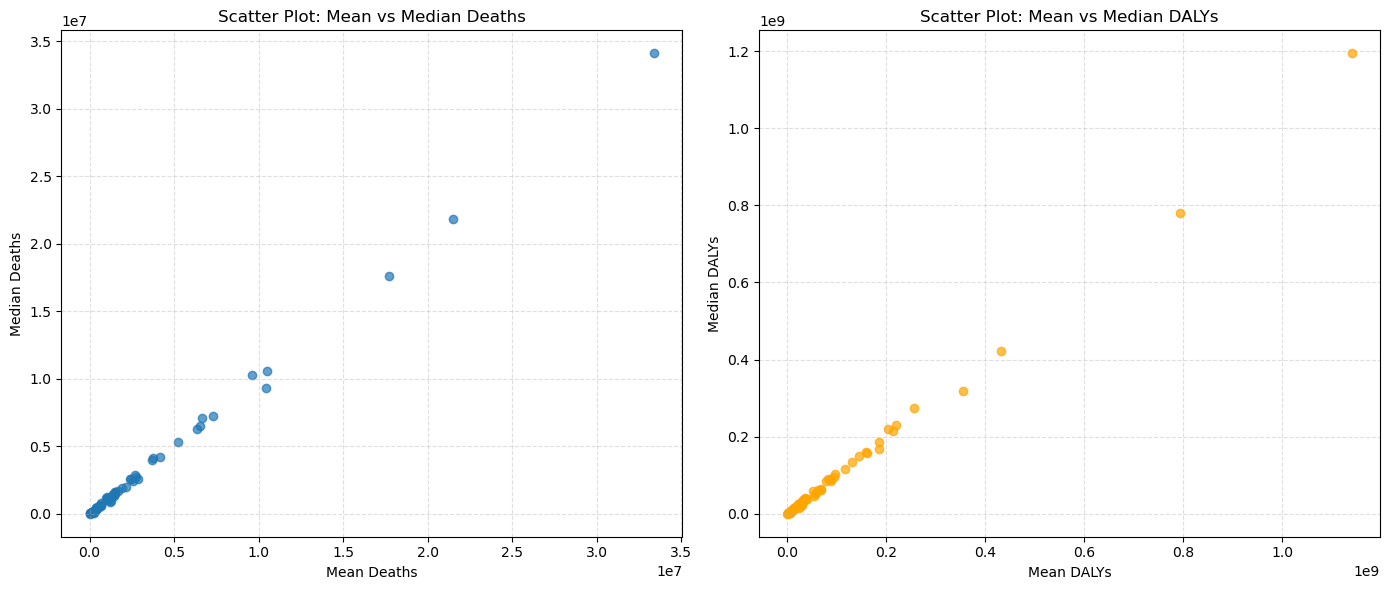

In [257]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Deaths
axes[0].scatter(summary_wide['mean_Deaths'], summary_wide['median_Deaths'], alpha=0.7)
axes[0].set_xlabel('Mean Deaths')
axes[0].set_ylabel('Median Deaths')
axes[0].set_title('Scatter Plot: Mean vs Median Deaths')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Scatter plot for DALYs
axes[1].scatter(summary_wide['mean_DALYs'], summary_wide['median_DALYs'], alpha=0.7, color='orange')
axes[1].set_xlabel('Mean DALYs')
axes[1].set_ylabel('Median DALYs')
axes[1].set_title('Scatter Plot: Mean vs Median DALYs')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Table 1: Median and range of estimates for deaths and DALYs

In [258]:
summary_wide=summary_wide.round(1)
summary_wide['Median Deaths (Min-Max)']=summary_wide['median_Deaths'].astype(str) + ' ('+ summary_wide['min_Deaths'].astype(str)+'-'+summary_wide['max_Deaths'].astype(str)+')'
summary_wide['Median DALYs (Min-Max)']=summary_wide['median_DALYs'].astype(str) + ' ('+ summary_wide['min_DALYs'].astype(str)+'-'+summary_wide['max_DALYs'].astype(str)+')'
summary_wide.to_csv('./tables/Supplementary Data File 1.csv')
table1=pd.concat([summary_wide[summary_wide['rmu_Deaths']>1.5],summary_wide[summary_wide['rmu_DALYs']>1.5]])
temporary = table1.drop_duplicates(subset=['Overarching_group', 'Group', 'Risk_factor'])
temporary[['Overarching_group','Group','Risk_factor','Median Deaths (Min-Max)','rmu_Deaths','Median DALYs (Min-Max)','rmu_DALYs','n_estimates_Deaths','n_estimates_DALYs', 'cv_Deaths','cv_DALYs']].to_csv('./tables/Table 1.csv')

In [259]:
temporary[['Overarching_group','Group','Risk_factor','Median Deaths (Min-Max)','rmu_Deaths','Median DALYs (Min-Max)','rmu_DALYs','n_estimates_Deaths','n_estimates_DALYs', 'cv_Deaths','cv_DALYs']]

,Overarching_group,Group,Risk_factor,Median Deaths (Min-Max),rmu_Deaths,Median DALYs (Min-Max),rmu_DALYs,n_estimates_Deaths,n_estimates_DALYs,cv_Deaths,cv_DALYs
4,Behavioural risks,Child and maternal malnutrition,Iron deficiency,51174.6 (20950.0-199000.0),2.4,38919563.5 (31263125.1-52870000.0),0.5,8.0,8,0.8,0.2
6,Behavioural risks,Child and maternal malnutrition,Suboptimal breastfeeding,160740.0 (101023.1-544817.0),1.7,14186625.0 (9139749.4-47537000.0),1.7,8.0,8,0.7,0.7
7,Behavioural risks,Child and maternal malnutrition,Vitamin A deficiency,62590.0 (17374.4-233000.0),2.8,5795025.0 (2663755.7-29000000.0),3.1,8.0,8,0.9,1.0
8,Behavioural risks,Child and maternal malnutrition,Zinc deficiency,27045.0 (1611.6-97330.0),2.7,2412825.0 (148447.0-9136000.0),2.8,8.0,8,1.0,1.0
9,Behavioural risks,Dietary risks,Diet high in processed meat,305676.9 (130000.0-840857.0),1.8,10122314.8 (3196040.0-20939000.0),1.6,8.0,8,0.6,0.6
10,Behavioural risks,Dietary risks,Diet high in red meat,72500.0 (25000.0-895674.9),3.8,3000000.0 (1247330.0-23861073.8),3.3,8.0,8,1.3,1.2
12,Behavioural risks,Dietary risks,Diet high in sugar sweetened beverages,131500.0 (22560.0-299521.0),2.0,5320000.0 (779510.0-8553000.0),1.6,8.0,8,0.7,0.6
28,Behavioural risks,Low physical activity,Low physical activity,1316670.0 (657618.7-3183940.0),1.7,24007930.0 (15704960.4-69318000.0),1.8,8.0,8,0.6,0.6
30,Behavioural risks,Tobacco,Chewing tobacco,66421.6 (55592.2-251383.3),1.8,1735925.5 (1504402.8-6483553.8),1.7,4.0,4,0.9,0.8
44,Environmental/occupational risks,Occupational risks,Occupational carcinogens,345111.4 (118097.0-746540.0),1.7,7529625.2 (2681000.0-20682730.0),2.1,8.0,8,0.5,0.6


In [ ]:
# Using your wide summary
sorted_df = compute_proportions(summary_wide, output_csv='./tables/eTable 3.csv')
sorted_df

,Overarching_group,Group,DALYs,Deaths
0,All risk factors,NaN,0/1 (0.0),0/1 (0.0)
0,All risk factors,Other,0/1 (0.0),0/1 (0.0)
1,Behavioural risks,NaN,14/34 (0.41),17/34 (0.5)
1,Behavioural risks,Child and maternal malnutrition,3/8 (0.38),4/8 (0.5)
2,Behavioural risks,Dietary risks,7/16 (0.44),9/16 (0.56)
3,Behavioural risks,Drug use,0/1 (0.0),0/1 (0.0)
4,Behavioural risks,High alcohol use,0/1 (0.0),0/1 (0.0)
5,Behavioural risks,Intimate partner violence,1/1 (1.0),1/1 (1.0)
6,Behavioural risks,Low physical activity,1/1 (1.0),1/1 (1.0)
7,Behavioural risks,Other,0/1 (0.0),0/1 (0.0)


## 2017-2023

In [261]:
summary_wide_cons, summary_wide = summarize_deaths_dalys_full(temps_comp, min_year=2016)
print('Median range/mean deaths risks 2017-2023: '+str(summary_wide.rmu_Deaths.median())+' ('+str(summary_wide.rmu_Deaths.min())+'-'+str(summary_wide.rmu_Deaths.max())+')',
    '\nMedian range/mean daly risks 2017-2023: '+str(summary_wide.rmu_DALYs.median())+' ('+str(summary_wide.rmu_DALYs.min())+'-'+str(summary_wide.rmu_DALYs.max())+')')

sorted_df = compute_proportions(summary_wide)
sorted_df

Median range/mean deaths risks 2017-2023: 0.4766650542110802 (0.026484446714403153-2.925885838174964) 
Median range/mean daly risks 2017-2023: 0.4294028357423967 (0.023377850780392076-2.7813555703771344)


,Overarching_group,Group,DALYs,Deaths
0,All risk factors,NaN,0/1 (0.0),0/1 (0.0)
0,All risk factors,Other,0/1 (0.0),0/1 (0.0)
1,Behavioural risks,NaN,10/33 (0.3),9/33 (0.27)
1,Behavioural risks,Child and maternal malnutrition,2/7 (0.29),2/7 (0.29)
2,Behavioural risks,Dietary risks,6/16 (0.38),6/16 (0.38)
3,Behavioural risks,Drug use,0/1 (0.0),0/1 (0.0)
4,Behavioural risks,High alcohol use,0/1 (0.0),0/1 (0.0)
5,Behavioural risks,Intimate partner violence,1/1 (1.0),0/1 (0.0)
6,Behavioural risks,Low physical activity,0/1 (0.0),0/1 (0.0)
7,Behavioural risks,Other,0/1 (0.0),0/1 (0.0)


## Matched risk-year pairs 

In [262]:
temps=temps[temps['anal_year']<=2021]
temps.shape

(5100, 10)

In [263]:
summary_wide_cons, summary_wide = summarize_deaths_dalys_full(temps,exclude_group='Other')
# here summary_wide is pointless to use.
summary_wide_cons.to_csv('./tables/Supplementary Data File 2.csv')

### Sanity check: assessment of need to use median v mean

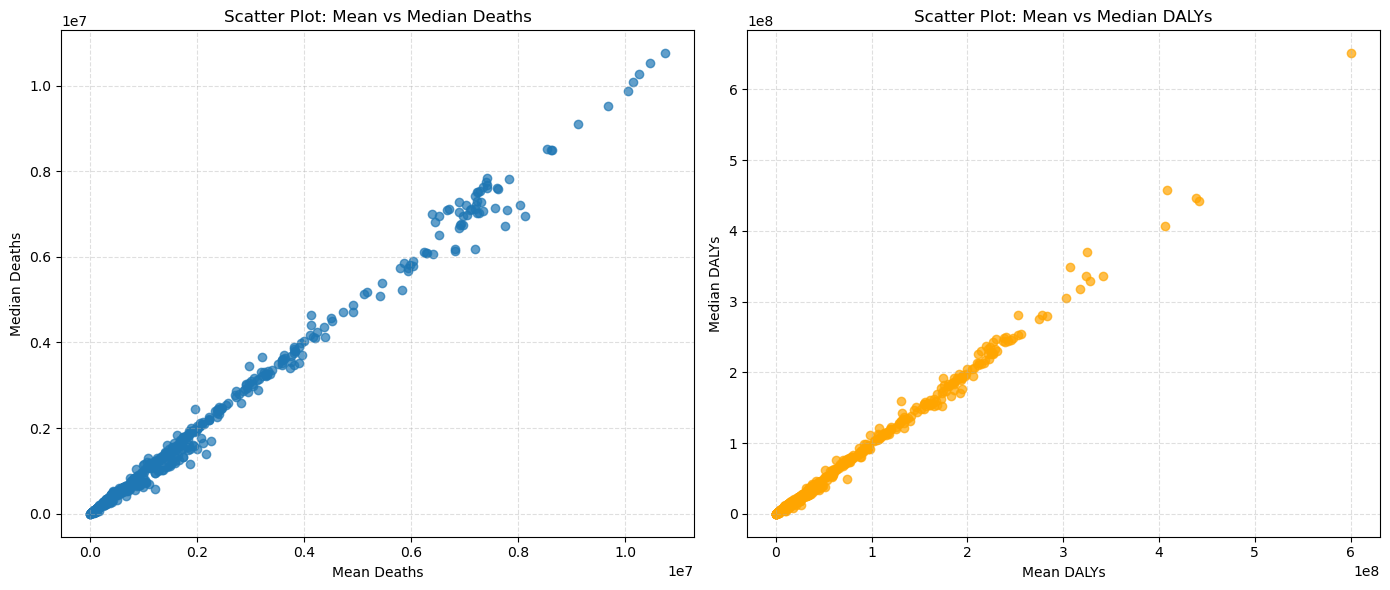

In [265]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Deaths
axes[0].scatter(summary_wide_cons['mean_Deaths'], summary_wide_cons['median_Deaths'], alpha=0.7)
axes[0].set_xlabel('Mean Deaths')
axes[0].set_ylabel('Median Deaths')
axes[0].set_title('Scatter Plot: Mean vs Median Deaths')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Scatter plot for DALYs
axes[1].scatter(summary_wide_cons['mean_DALYs'], summary_wide_cons['median_DALYs'], alpha=0.7, color='orange')
axes[1].set_xlabel('Mean DALYs')
axes[1].set_ylabel('Median DALYs')
axes[1].set_title('Scatter Plot: Mean vs Median DALYs')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [266]:
pivoted = format_and_pivot_summary(summary_wide_cons, value_cols=('DALYs','Deaths'))

# Access the pivoted DALYs table
summary_wide_cons_wide = pivoted['Deaths']
summary_wide_cons_wide.to_csv('./data/processed_data/Rawdata for Heatmap.csv')
summary_wide_cons_wide

anal_year,1990,2005,2006,2007,2010,2013,2015,2016,2017,2019,2021
Risk_factor,,,,,,,,,,,
Air pollution,6804 (4808-7341) [0.4],7110 (6466-8099) [0.2],7096 (6220-7954) [0.2],7115 (4630-7943) [0.5],7670 (6576-8022) [0.2],7205 (5527-8157) [0.4],7276 (6485-8210) [0.2],7314 (6116-8203) [0.3],7291 (4900-8123) [0.5],7617 (6672-7966) [0.2],7823 (7565-8080) [0.1]
Ambient ozone pollution,173 (133-235) [0.6],315 (207-359) [0.5],331 (188-371) [0.6],377 (330-392) [0.2],332 (152-390) [0.8],330 (217-393) [0.6],340 (254-410) [0.5],363 (234-438) [0.6],430 (356-472) [0.3],404 (365-470) [0.3],436 (381-490) [0.2]
Ambient particulate matter pollution,2336 (2047-2910) [0.4],3255 (2913-3934) [0.3],3242 (2951-3687) [0.2],3033 (2420-3302) [0.3],3359 (3224-3617) [0.1],3699 (2926-4240) [0.4],4241 (3871-4583) [0.2],4093 (3876-4630) [0.2],3882 (2940-4612) [0.4],4372 (4141-4602) [0.1],4719 (4719-4719) [0.0]
Chewing tobacco,25 (25-108) [1.6],37 (37-151) [1.5],38 (38-159) [1.6],49 (39-166) [1.7],41 (41-178) [1.6],45 (44-192) [1.6],48 (47-203) [1.6],50 (49-214) [1.6],64 (51-222) [1.7],56 (54-227) [1.5],153 (57-248) [1.3]
Child and maternal malnutrition,7001 (4254-7332) [0.5],4636 (2280-4954) [0.6],4498 (4301-4795) [0.1],4563 (4259-4650) [0.1],4165 (3944-4235) [0.1],3669 (1665-3838) [0.7],3452 (1414-3545) [0.7],3318 (2737-3402) [0.2],3208 (3155-3256) [0.0],2938 (2911-2951) [0.0],2578 (2573-2582) [0.0]
Child growth failure,3903 (3675-4112) [0.1],2221 (2200-2243) [0.0],2107 (1875-2131) [0.1],2006 (1980-2031) [0.0],1820 (1733-1825) [0.1],1548 (1503-1563) [0.0],1411 (1347-1439) [0.1],1304 (1011-1381) [0.3],1234 (1190-1327) [0.1],1104 (1065-1198) [0.1],950 (888-1012) [0.1]
Childhood undernutrition,3635 (3635-3635) [0.0],2093 (2093-2093) [0.0],NaN,NaN,NaN,1327 (1327-1327) [0.0],1265 (1265-1265) [0.0],NaN,NaN,NaN,NaN
Diet high in processed meat,243 (218-732) [1.4],291 (241-476) [0.7],254 (147-297) [0.6],253 (125-290) [0.7],275 (240-841) [1.5],273 (244-644) [1.1],280 (255-541) [0.8],270 (140-288) [0.6],274 (130-291) [0.7],290 (274-304) [0.1],293 (290-295) [0.0]
Diet high in red meat,180 (26-578) [2.7],216 (37-719) [2.3],219 (23-713) [2.4],224 (17-717) [2.4],243 (38-756) [2.2],267 (102-786) [1.9],285 (43-818) [2.2],293 (32-836) [2.2],303 (25-850) [2.2],321 (315-896) [1.1],336 (334-338) [0.0]


In [267]:
print('Median range/mean deaths risks 1990-2021: '+str(summary_wide_cons.rmu_Deaths.median())+' ('+str(summary_wide_cons.rmu_Deaths.min())+'-'+str(summary_wide_cons.rmu_Deaths.max())+')',
    '\nIQR '+ str(summary_wide_cons['rmu_Deaths'].quantile(0.25))+'-'+str(summary_wide_cons['rmu_Deaths'].quantile(0.75)),
    '\nMedian range/mean daly risks 1990-2021: '+str(summary_wide_cons.rmu_DALYs.median())+' ('+str(summary_wide_cons.rmu_DALYs.min())+'-'+str(summary_wide_cons.rmu_DALYs.max())+')' + '',
    '\nIQR '+ str(summary_wide_cons['rmu_DALYs'].quantile(0.25))+'-'+str(summary_wide_cons['rmu_DALYs'].quantile(0.75))
    )

# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Behavioural risks'].rmu_Deaths.median(skipna=True)
environmental_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Environmental/occupational risks'].rmu_Deaths.median(skipna=True)
metabolic_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Metabolic risks'].rmu_Deaths.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M (Deaths): {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M (Deaths): {environmental_risks_median}")
print(f"Metabolic risks median R/M (Deaths): {metabolic_risks_median}")

# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Behavioural risks'].rmu_DALYs.median(skipna=True)
environmental_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Environmental/occupational risks'].rmu_DALYs.median(skipna=True)
metabolic_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Metabolic risks'].rmu_DALYs.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M (DALYs): {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M (DALYs): {environmental_risks_median}")
print(f"Metabolic risks median R/M (DALYs): {metabolic_risks_median}")

Median range/mean deaths risks 1990-2021: 0.4 (0.0-2.9) 
IQR 0.2-0.9 
Median range/mean daly risks 1990-2021: 0.4 (0.0-2.9) 
IQR 0.2-0.8
Behavioural risks median R/M (Deaths): 0.7
Environmental/occupational risks median R/M (Deaths): 0.3
Metabolic risks median R/M (Deaths): 0.3
Behavioural risks median R/M (DALYs): 0.6
Environmental/occupational risks median R/M (DALYs): 0.3
Metabolic risks median R/M (DALYs): 0.25


In [ ]:
# Using your wide summary
sorted_df = compute_proportions(summary_wide_cons, output_csv='./tables/eTable 4.csv')
sorted_df

,Overarching_group,Group,DALYs,Deaths
0,Behavioural risks,NaN,87/356 (0.24),111/356 (0.31)
0,Behavioural risks,Child and maternal malnutrition,14/81 (0.17),19/81 (0.23)
1,Behavioural risks,Dietary risks,55/176 (0.31),74/176 (0.42)
2,Behavioural risks,Drug use,0/11 (0.0),0/11 (0.0)
3,Behavioural risks,High alcohol use,0/11 (0.0),0/11 (0.0)
4,Behavioural risks,Intimate partner violence,1/11 (0.09),1/11 (0.09)
5,Behavioural risks,Low physical activity,5/11 (0.45),5/11 (0.45)
6,Behavioural risks,Tobacco,12/44 (0.27),12/44 (0.27)
7,Behavioural risks,Unsafe sex,0/11 (0.0),0/11 (0.0)
1,Environmental/occupational risks,NaN,28/253 (0.11),24/253 (0.09)


### Risks R/M > 1.5

In [269]:
pd.set_option('display.max_rows', 200)
temporary=summary_wide_cons[(summary_wide_cons['rmu_Deaths']>1.5)&(summary_wide_cons['rmu_Deaths']<5)]
temporary['Risk_factor']+' '+temporary['anal_year'].astype(str)


31                             Iron deficiency 2013
62                        Vitamin A deficiency 2007
67                        Vitamin A deficiency 2017
70                             Zinc deficiency 1990
71                             Zinc deficiency 2005
72                             Zinc deficiency 2006
73                             Zinc deficiency 2007
74                             Zinc deficiency 2010
75                             Zinc deficiency 2013
76                             Zinc deficiency 2015
77                             Zinc deficiency 2016
78                             Zinc deficiency 2017
92                       Diet high in red meat 1990
93                       Diet high in red meat 2005
94                       Diet high in red meat 2006
95                       Diet high in red meat 2007
96                       Diet high in red meat 2010
97                       Diet high in red meat 2013
98                       Diet high in red meat 2015
99          

### CV values

In [271]:
# Calculate the percentage of rows with cv_Deaths > 0.2
percentage_cv_deaths = (summary_wide_cons['cv_Deaths'] > 0.2).mean() * 100

# Calculate the percentage of rows with cv_DALYs > 0.2
percentage_cv_dalys = (summary_wide_cons['cv_DALYs'] > 0.2).mean() * 100

print(f"Percentage of rows with cv_Deaths > 0.2: {percentage_cv_deaths:.2f}%, n={(summary_wide_cons['cv_Deaths'] > 0.2).sum()}")
print(f"Percentage of rows with cv_DALYs > 0.2: {percentage_cv_dalys:.2f}%, n={(summary_wide_cons['cv_DALYs'] > 0.2).sum()}")

# Calculate the percentage of rows with cv_Deaths > 0.2
percentage_cv_deaths = (summary_wide_cons['cv_Deaths'] > 0.5).mean() * 100

# Calculate the percentage of rows with cv_DALYs > 0.2
percentage_cv_dalys = (summary_wide_cons['cv_DALYs'] > 0.5).mean() * 100

print(f"Percentage of rows with cv_Deaths > 0.5: {percentage_cv_deaths:.2f}%, n={(summary_wide_cons['cv_Deaths'] > 0.5).sum()}")
print(f"Percentage of rows with cv_DALYs > 0.5: {percentage_cv_dalys:.2f}%, n={(summary_wide_cons['cv_DALYs'] > 0.5).sum()}")


Percentage of rows with cv_Deaths > 0.2: 49.78%, n=336
Percentage of rows with cv_DALYs > 0.2: 48.30%, n=326
Percentage of rows with cv_Deaths > 0.5: 18.81%, n=127
Percentage of rows with cv_DALYs > 0.5: 15.85%, n=107


In [ ]:
# Create columns for cv_Deaths > 0.2 and cv_DALYs > 0.2
df['cv_Deaths > 0.2'] = df['cv_Deaths'] > 0.2
df['cv_DALYs > 0.2'] = df['cv_DALYs'] > 0.2

# Calculate the percentage of rows with cv_Deaths > 0.2 by Group
percentage_cv_deaths_by_group = df.groupby('Group')['cv_Deaths > 0.2'].mean() * 100

# Calculate the percentage of rows with cv_DALYs > 0.2 by Group
percentage_cv_dalys_by_group = df.groupby('Group')['cv_DALYs > 0.2'].mean() * 100

# Print the results
print("Percentage of rows with cv_Deaths/cv_DALYs > 0.2 by Group:")
print(pd.concat([percentage_cv_deaths_by_group, percentage_cv_dalys_by_group],axis=1 ))

Percentage of rows with cv_Deaths/cv_DALYs > 0.2 by Group:
                                           cv_Deaths > 0.2  cv_DALYs > 0.2
Group                                                                     
Air pollution                                    29.090909       38.181818
Child and maternal malnutrition                  44.444444       38.271605
Dietary risks                                    84.090909       77.840909
Drug use                                         18.181818       18.181818
High LDL cholesterol*                             9.090909       18.181818
High alcohol use                                100.000000       72.727273
High body-mass index                             90.909091        9.090909
High fasting plasma glucose                       0.000000        0.000000
High systolic blood pressure                      0.000000        0.000000
Intimate partner violence                       100.000000       90.909091
Kidney dysfunction*                      

# Dietary deep dive

In [ ]:
# # Filter rows with anal_year 2023 and extract their unique combinations of specified columns
# reference_combinations = dfs[dfs['anal_year'] == 2023][['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id']]

# # Create a set of tuples for faster lookup
# reference_set = set(reference_combinations.itertuples(index=False, name=None))

# # Filter rows with anal_year 2019 and 2021 that are not in the reference set
# filtered_dfs = dfs[
#     ~((dfs['anal_year'].isin([2019, 2021])) & 
#       (~dfs[['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id']]
#         .apply(tuple, axis=1)
#         .isin(reference_set)))
# ]
# filtered_dfs.to_csv('./data/total_filtered.csv', index=False)

In [ ]:
dfs=filtered_dfs[filtered_dfs['anal_year'].isin([2019,2021])]

In [ ]:
# Filter out groups that do not have at least two unique anal_year values (baseline comparator)
# Create a mask to identify groups with more than one unique anal_year
mask = dfs.groupby(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'])['anal_year'] \
    .transform('nunique') > 1

# Apply the mask to filter the DataFrame
valid_groups = dfs[mask]
valid_groups.set_index(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'], inplace=True)
reference_anal_year=2021
reference_df = valid_groups[valid_groups['anal_year'] == reference_anal_year]
valid_groups=valid_groups[valid_groups['anal_year'] != reference_anal_year]

# Merge valid_groups (various years) with reference_df (2021 data) based on the index
merged_df = valid_groups[['val']].merge(
    reference_df[['val']], 
    left_index=True, 
    right_index=True, 
    suffixes=('_2019', '_2021')  # Rename columns for clarity
)

# Compute Pearson correlation using .corr()
#correlation = merged_df.corr().loc['estimate_other', 'estimate_2021']

#grouped_corr = merged_df.groupby(level=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id']).corr().unstack().loc[:, ('estimate_other', 'estimate_2021')]

# Create a multi-level pivot table where '2019' and '2021' estimates are columns
pivot_df = merged_df.pivot_table(index=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id'],
                                 values=['val_2019', 'val_2021'])

merged_df.dropna(subset=['val_2019', 'val_2021'], inplace=True)

In [ ]:
merged_df = valid_groups.join(reference_df[['val', 'lower', 'upper']], rsuffix='_ref', how='inner')

In [ ]:
from pandarallel import pandarallel# parallel apply
pandarallel.initialize()
merged_df['position'] = merged_df.parallel_apply(interval_position, axis=1)
merged_df['interval_overlap'] = merged_df.parallel_apply(intervals_overlap, axis=1)

# Extract the results
results_df = merged_df.reset_index()[[
    'anal_year', 'year', 'sex_id', 'sex_name', 'rei_id', 'rei_name','measure_name',
    'lower', 'upper', 'val','val_ref','lower_ref','upper_ref', 'position', 'interval_overlap'
]]

results_df=results_df[results_df['measure_name'].isin(['Deaths','DALYs (Disability-Adjusted Life Years)'])]
results_df.to_csv('./data/dietary_deep_dive_1921.csv', index=False)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [ ]:
measure_names = results_df['measure_name'].unique()
for measure in measure_names:
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    print(f"\nMeasure: {measure}")
    print(percentages[percentages['within']<0.5])
    #print(percentages)


Measure: DALYs (Disability-Adjusted Life Years)
position                                    above     below    within
rei_name                                                             
Diet high in red meat                    0.000000  0.834921  0.165079
Diet high in sugar-sweetened beverages   0.000000  0.738095  0.261905
Diet low in fruits                       0.719841  0.000000  0.280159
Diet low in polyunsaturated fatty acids  0.680952  0.000000  0.319048
Diet low in seafood omega-3 fatty acids  0.961905  0.000000  0.038095
Diet low in vegetables                   0.713492  0.000000  0.286508

Measure: Deaths
position                                    above     below    within
rei_name                                                             
Diet high in red meat                    0.000000  0.836508  0.163492
Diet high in sugar-sweetened beverages   0.000000  0.959524  0.040476
Diet low in calcium                      0.000000  0.512698  0.487302
Diet low in fruits      

In [ ]:
measure_names = results_df['measure_name'].unique()
for measure in measure_names:
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    breakdown['Total'] = total_counts
    print(f"\nMeasure: {measure}")
    print(breakdown)


Measure: DALYs (Disability-Adjusted Life Years)
position                                 above  below  within  Total
rei_name                                                            
Diet high in processed meat                108    102    1050   1260
Diet high in red meat                        0   1052     208   1260
Diet high in sodium                          0      0    1260   1260
Diet high in sugar-sweetened beverages       0    930     330   1260
Diet high in trans fatty acids               0    498     762   1260
Diet low in calcium                         12    584     664   1260
Diet low in fiber                            0      0    1260   1260
Diet low in fruits                         907      0     353   1260
Diet low in legumes                          0      0    1260   1260
Diet low in milk                            30    168    1062   1260
Diet low in nuts and seeds                  66      0    1194   1260
Diet low in polyunsaturated fatty acids    858      0 

In [ ]:
dfs=filtered_dfs[filtered_dfs['anal_year'].isin([2021,2023])]

In [ ]:
dfs.year.unique()

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023])

In [ ]:
# Filter out groups that do not have at least two unique anal_year values (baseline comparator)
# Create a mask to identify groups with more than one unique anal_year
mask = dfs.groupby(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'])['anal_year'] \
    .transform('nunique') > 1

# Apply the mask to filter the DataFrame
valid_groups = dfs[mask]
valid_groups.set_index(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'], inplace=True)
reference_anal_year=2023
reference_df = valid_groups[valid_groups['anal_year'] == reference_anal_year]
valid_groups=valid_groups[valid_groups['anal_year'] != reference_anal_year]

# Merge valid_groups (various years) with reference_df (2021 data) based on the index
merged_df = valid_groups[['val']].merge(
    reference_df[['val']], 
    left_index=True, 
    right_index=True, 
    suffixes=('_2021', '_2023')  # Rename columns for clarity
)

# Compute Pearson correlation using .corr()
#correlation = merged_df.corr().loc['estimate_other', 'estimate_2021']

#grouped_corr = merged_df.groupby(level=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id']).corr().unstack().loc[:, ('estimate_other', 'estimate_2021')]

# Create a multi-level pivot table where '2019' and '2021' estimates are columns
pivot_df = merged_df.pivot_table(index=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id'],
                                 values=['val_2021', 'val_2023'])

merged_df.dropna(subset=['val_2021', 'val_2023'], inplace=True)

In [ ]:
merged_df = valid_groups.join(reference_df[['val', 'lower', 'upper']], rsuffix='_ref', how='inner')

In [ ]:
from pandarallel import pandarallel# parallel apply
pandarallel.initialize()
merged_df['position'] = merged_df.parallel_apply(interval_position, axis=1)
merged_df['interval_overlap'] = merged_df.parallel_apply(intervals_overlap, axis=1)

# Extract the results
results_df = merged_df.reset_index()[[
    'anal_year', 'year', 'sex_id', 'sex_name', 'rei_id', 'rei_name','measure_name',
    'lower', 'upper', 'val','val_ref','lower_ref','upper_ref', 'position', 'interval_overlap'
]]

results_df=results_df[results_df['measure_name'].isin(['Deaths','DALYs (Disability-Adjusted Life Years)'])]
results_df.to_csv('./data/dietary_deep_dive_2123.csv', index=False)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [ ]:
measure_names = results_df['measure_name'].unique()
for measure in measure_names:
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    print(f"\nMeasure: {measure}")
    print(percentages[percentages['within']<0.5])
    #print(percentages)


Measure: Deaths
position                           above  below    within
rei_name                                                 
Diet high in trans fatty acids  0.738095    0.0  0.261905

Measure: DALYs (Disability-Adjusted Life Years)
position                          above  below   within
rei_name                                               
Diet high in trans fatty acids  0.77381    0.0  0.22619


In [ ]:
measure_names = results_df['measure_name'].unique()
for measure in measure_names:
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    breakdown['Total'] = total_counts
    print(f"\nMeasure: {measure}")
    print(breakdown)


Measure: Deaths
position                                 above  below  within  Total
rei_name                                                            
Diet high in processed meat                  0      0    2016   2016
Diet high in red meat                       39      0    1977   2016
Diet high in sodium                          0      0    1344   1344
Diet high in sugar-sweetened beverages     921      9    1086   2016
Diet high in trans fatty acids             992      0     352   1344
Diet low in calcium                         34    146    1164   1344
Diet low in fiber                            0     80    1264   1344
Diet low in fruits                           2      0    2011   2013
Diet low in legumes                          0      0    1344   1344
Diet low in milk                             0      0    1344   1344
Diet low in nuts and seeds                 222      0    1122   1344
Diet low in polyunsaturated fatty acids      0      0    1344   1344
Diet low in seafo

In [ ]:
dfs=filtered_dfs[filtered_dfs['anal_year'].isin([2019,2023])]

In [ ]:
# Filter out groups that do not have at least two unique anal_year values (baseline comparator)
# Create a mask to identify groups with more than one unique anal_year
mask = dfs.groupby(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'])['anal_year'] \
    .transform('nunique') > 1

# Apply the mask to filter the DataFrame
valid_groups = dfs[mask]
valid_groups.set_index(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'], inplace=True)
reference_anal_year=2023
reference_df = valid_groups[valid_groups['anal_year'] == reference_anal_year]
valid_groups=valid_groups[valid_groups['anal_year'] != reference_anal_year]

# Merge valid_groups (various years) with reference_df (2021 data) based on the index
merged_df = valid_groups[['val']].merge(
    reference_df[['val']], 
    left_index=True, 
    right_index=True, 
    suffixes=('_2019', '_2023')  # Rename columns for clarity
)

# Compute Pearson correlation using .corr()
#correlation = merged_df.corr().loc['estimate_other', 'estimate_2021']

#grouped_corr = merged_df.groupby(level=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id']).corr().unstack().loc[:, ('estimate_other', 'estimate_2021')]

# Create a multi-level pivot table where '2019' and '2021' estimates are columns
pivot_df = merged_df.pivot_table(index=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id'],
                                 values=['val_2019', 'val_2023'])

merged_df.dropna(subset=['val_2019', 'val_2023'], inplace=True)

merged_df = valid_groups.join(reference_df[['val', 'lower', 'upper']], rsuffix='_ref', how='inner')

from pandarallel import pandarallel# parallel apply
pandarallel.initialize()
merged_df['position'] = merged_df.parallel_apply(interval_position, axis=1)
merged_df['interval_overlap'] = merged_df.parallel_apply(intervals_overlap, axis=1)

# Extract the results
results_df = merged_df.reset_index()[[
    'anal_year', 'year', 'sex_id', 'sex_name', 'rei_id', 'rei_name','measure_name',
    'lower', 'upper', 'val','val_ref','lower_ref','upper_ref', 'position', 'interval_overlap'
]]

results_df=results_df[results_df['measure_name'].isin(['Deaths','DALYs (Disability-Adjusted Life Years)'])]
#results_df.to_csv('./data/dietary_deep_dive_1921.csv', index=False)

measure_names = results_df['measure_name'].unique()
for measure in measure_names:
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    print(f"\nMeasure: {measure}")
    print(percentages[percentages['within']<0.5])
    #print(percentages)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

Measure: DALYs (Disability-Adjusted Life Years)
position                                    above     below    within
rei_name                                                             
Diet high in red meat                    0.000000  0.799206  0.200794
Diet high in sugar-sweetened beverages   0.137302  0.513492  0.349206
Diet low in calcium                      0.068254  0.492063  0.439683
Diet low in fruits                       0.765873  0.000000  0.234127
Diet low in nuts and seeds               0.865079  0.000000  0.134921
Diet low in seafood omega-3 fatty acids  0.957143  0.000000  0.042857
Diet low in vegetables                   0.778571  0.000000  0.221429

Measure: Deaths
position                                    above     below    within
rei_name                                                         

In [ ]:
results_df=pd.read_csv('./data/processed_data/dietary_deep_dive_1921.csv')

In [ ]:
results_df.columns

Index(['anal_year', 'year', 'sex_id', 'sex_name', 'rei_id', 'rei_name',
       'measure_name', 'lower', 'upper', 'val', 'val_ref', 'lower_ref',
       'upper_ref', 'position', 'interval_overlap'],
      dtype='object')

In [ ]:
temps[(temps['year_gbd']==2023)&(temps['anal_year']==2007)]

,Level,Risk_factor,measure,year_gbd,anal_year,val,lower,upper,Group,Overarching_group
